# Publication-Ready Visualizations

This notebook produces all charts used in the portfolio, Kaggle notebook,
and social posts for this project.

It is structured in two sections:

**Section A — Behavioral Findings**
The five charts that answer the central question: do the playing patterns
show signs of compulsive use?

1. Daily game volume over six years
2. Requeue speed by result (win / draw / loss)
3. Late night play — volume and performance by time block
4. Session length distribution and performance by session length
5. Yearly volume trend

**Section B — Player Profile**
Supporting context about who the player is and how they play.

6. Rating progression
7. Performance by hour of day
8. White vs black performance
9. Best performing openings

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np
import sys
from pathlib import Path

## Load data

In [3]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
    / f"{USERNAME}_games_clean.csv"
)

PLOTS_DIR = PROJECT_ROOT / "plots" / USERNAME
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Total games: {len(df):,}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")

Total games: 21,007
Date range: 2020-11-10 -> 2026-05-08


## Global style

In [4]:
sns.set_theme(style="ticks", palette="deep", font_scale=1.2)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titleweight": "bold",
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

---

# Section A — Behavioral Findings

These five charts directly answer the central question of this project.
Each one isolates a different behavioral signal.

## Chart 1 — Daily Game Volume

Binge days (95th percentile and above) are highlighted in red.
The 30-day rolling average reveals the underlying trend beneath the noise.

In [5]:
daily = (
    df.groupby(df["date"].dt.date)
    .size()
    .reset_index(name="games")
)
daily["date"] = pd.to_datetime(daily["date"])
daily["rolling_avg"] = daily["games"].rolling(30, center=True).mean()

binge_threshold = daily["games"].quantile(0.95)
binge_days = daily[daily["games"] >= binge_threshold]

print(f"Binge threshold (95th pct): {binge_threshold:.0f} games/day")
print(f"Number of binge days: {len(binge_days)}")
print(f"Max games in a single day: {daily['games'].max()}")

Binge threshold (95th pct): 38 games/day
Number of binge days: 93
Max games in a single day: 93


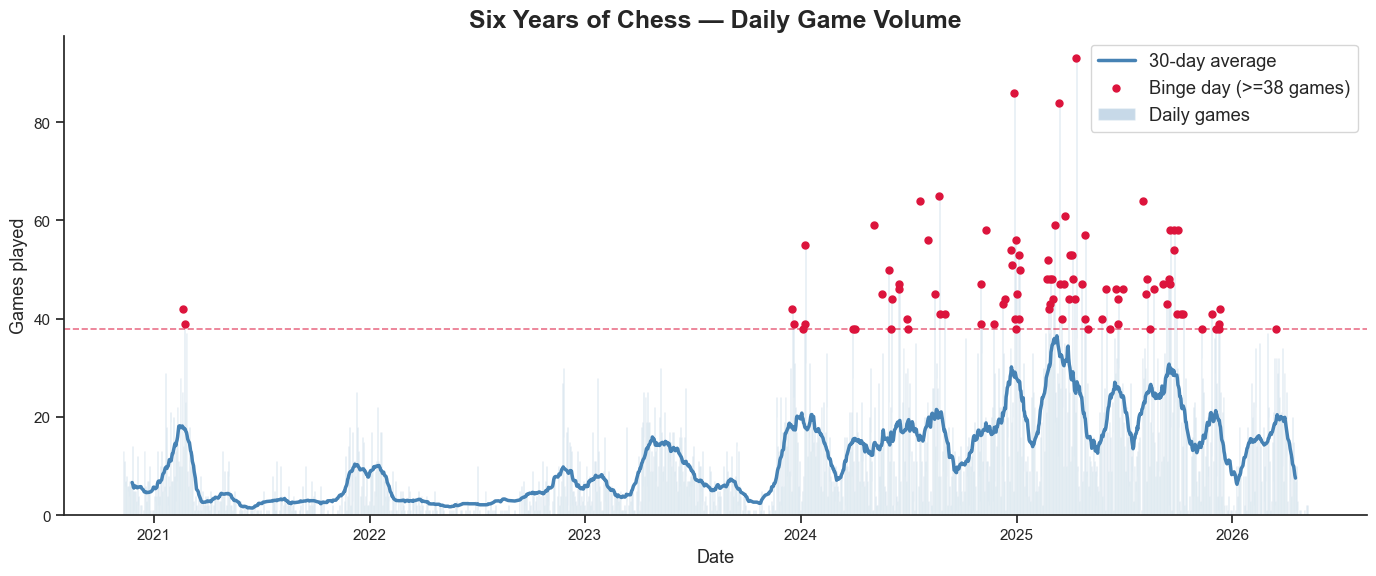

In [6]:
fig, ax = plt.subplots()

ax.bar(
    daily["date"],
    daily["games"],
    color="steelblue",
    alpha=0.3,
    width=1,
    label="Daily games"
)
ax.plot(
    daily["date"],
    daily["rolling_avg"],
    color="steelblue",
    linewidth=2.5,
    label="30-day average"
)
ax.scatter(
    binge_days["date"],
    binge_days["games"],
    color="crimson",
    s=25,
    zorder=5,
    label=f"Binge day (>={binge_threshold:.0f} games)"
)
ax.axhline(
    binge_threshold,
    color="crimson",
    linestyle="--",
    alpha=0.6,
    linewidth=1.2
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Six Years of Chess — Daily Game Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Games played")
ax.legend()

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "01_daily_volume.png", dpi=300, bbox_inches="tight")

## Chart 2 — Requeue Speed by Result

How quickly does the player start a new game after a win, draw, or loss?

The original hypothesis was tilt: the player would requeue fastest after losses.
The data showed the opposite — a reward and tension loop driven by draws and wins.

Note: result classification uses the cleaned `result` column which correctly
captures all draw subtypes (agreed, stalemate, repetition, insufficient, etc.).

In [7]:
df["next_game_start"] = df["date"].shift(-1)
df["gap_seconds"] = (
    df["next_game_start"] - df["date"]
).dt.total_seconds()

requeue = df[
    (df["gap_seconds"] > 10) &
    (df["gap_seconds"] < 7200)
].copy()

requeue["gap_minutes"] = requeue["gap_seconds"] / 60
requeue["result_label"] = requeue["result"]

print("Median requeue time by result (minutes):")
print(
    requeue.groupby("result_label")["gap_minutes"]
    .median()
    .sort_values()
    .round(2)
)

Median requeue time by result (minutes):
result_label
draw    6.02
win     6.30
loss    8.17
Name: gap_minutes, dtype: float64


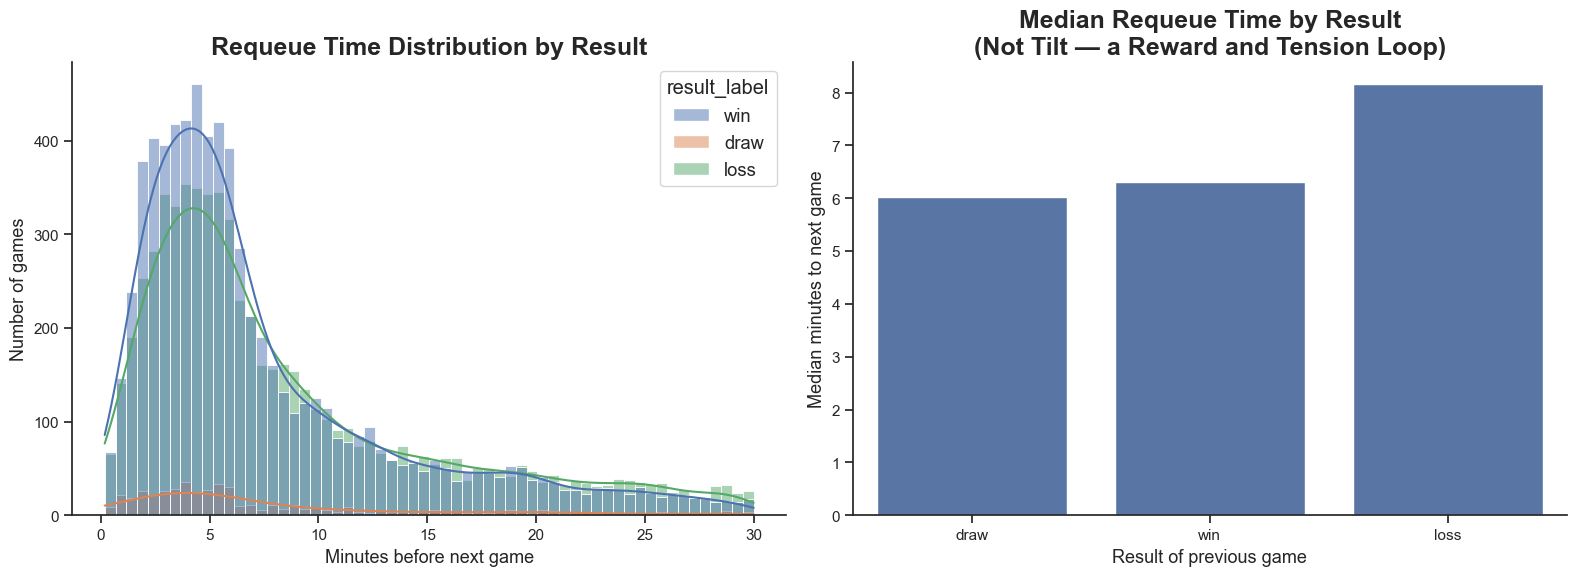

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.histplot(
    data=requeue[requeue["gap_minutes"] <= 30],
    x="gap_minutes",
    hue="result_label",
    hue_order=["win", "draw", "loss"],
    kde=True,
    bins=60,
    alpha=0.5,
    ax=ax
)
ax.set_title("Requeue Time Distribution by Result")
ax.set_xlabel("Minutes before next game")
ax.set_ylabel("Number of games")
sns.despine(ax=ax)

ax2 = axes[1]
median_requeue = (
    requeue.groupby("result_label")["gap_minutes"]
    .median()
    .reset_index()
    .sort_values("gap_minutes")
)
sns.barplot(
    data=median_requeue,
    x="result_label",
    y="gap_minutes",
    order=["draw", "win", "loss"],
    ax=ax2
)
ax2.set_title("Median Requeue Time by Result\n(Not Tilt — a Reward and Tension Loop)")
ax2.set_xlabel("Result of previous game")
ax2.set_ylabel("Median minutes to next game")
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "02_requeue_speed.png", dpi=300, bbox_inches="tight")

## Chart 3 — Late Night Play

Volume and win rate split by time of day block.
Late night (22:00-05:00) is highlighted in red.

In [9]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning\n(5-12)"
    elif 12 <= hour < 18:
        return "Afternoon\n(12-18)"
    elif 18 <= hour < 22:
        return "Evening\n(18-22)"
    else:
        return "Late night\n(22-5)"

df["time_block"] = df["hour"].apply(time_of_day)

block_order = [
    "Morning\n(5-12)",
    "Afternoon\n(12-18)",
    "Evening\n(18-22)",
    "Late night\n(22-5)"
]

time_stats = (
    df.groupby("time_block")
    .agg(
        games=("url", "count"),
        win_rate=("score", "mean")
    )
    .reset_index()
)
time_stats["time_block"] = pd.Categorical(
    time_stats["time_block"],
    categories=block_order,
    ordered=True
)
time_stats = time_stats.sort_values("time_block")

late_pct = (
    df[df["time_block"] == "Late night\n(22-5)"].shape[0]
    / len(df) * 100
)
print(f"Late night games: {late_pct:.1f}% of all games")

Late night games: 21.0% of all games


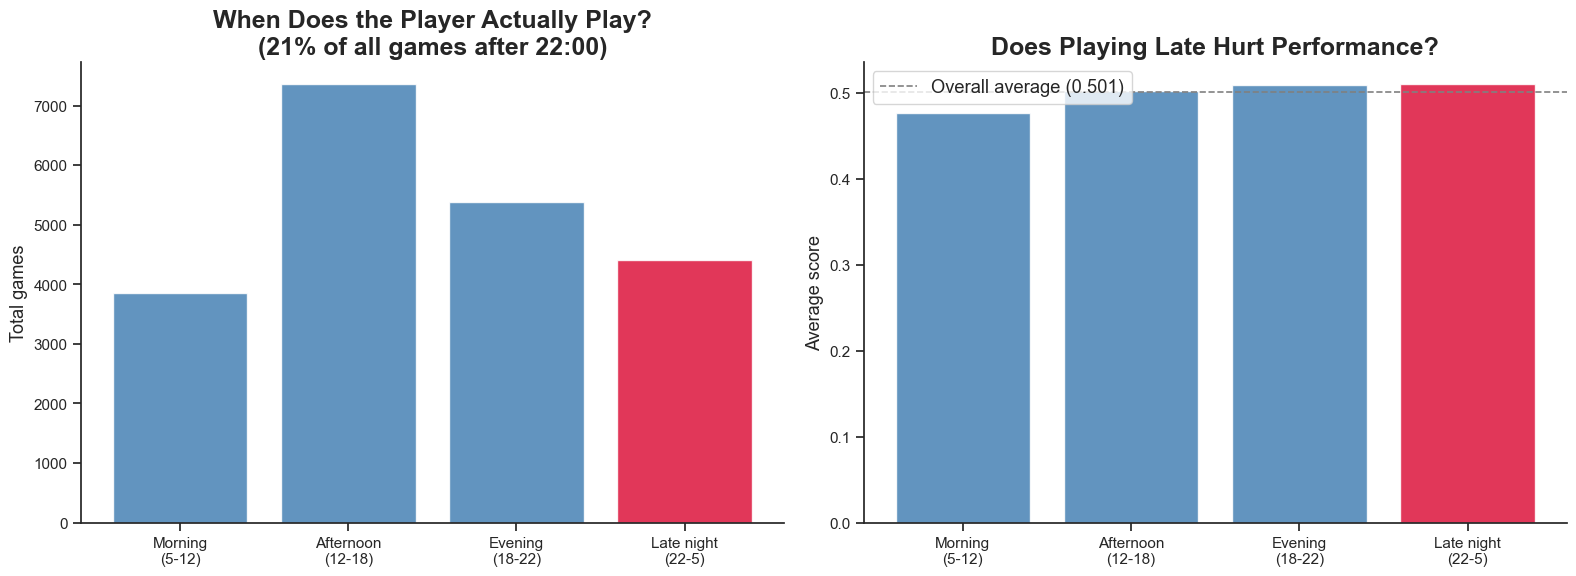

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

late_night_label = "Late night\n(22-5)"
bar_colors = [
    "crimson" if b == late_night_label else "steelblue"
    for b in block_order
]

ax = axes[0]
ax.bar(
    time_stats["time_block"],
    time_stats["games"],
    color=bar_colors,
    alpha=0.85
)
ax.set_title(
    f"When Does the Player Actually Play?\n"
    f"({late_pct:.0f}% of all games after 22:00)"
)
ax.set_xlabel("")
ax.set_ylabel("Total games")
sns.despine(ax=ax)

ax2 = axes[1]
ax2.bar(
    time_stats["time_block"],
    time_stats["win_rate"],
    color=bar_colors,
    alpha=0.85
)
ax2.axhline(
    df["score"].mean(),
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall average ({df['score'].mean():.3f})"
)
ax2.set_title("Does Playing Late Hurt Performance?")
ax2.set_xlabel("")
ax2.set_ylabel("Average score")
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "03_late_night.png", dpi=300, bbox_inches="tight")

## Chart 4 — Session Length

A session is a continuous block of games with no gap exceeding 2 hours.
Left: how long sessions typically are. Right: does performance drop as sessions get longer?

In [11]:
SESSION_GAP_HOURS = 2

df["gap_to_next"] = (
    df["date"].shift(-1) - df["date"]
).dt.total_seconds() / 3600

df["new_session"] = (
    df["gap_to_next"].shift(1).isna() |
    (df["gap_to_next"].shift(1) > SESSION_GAP_HOURS)
)
df["session_id"] = df["new_session"].cumsum()

sessions = (
    df.groupby("session_id")
    .agg(
        games=("url", "count"),
        session_start=("date", "min"),
        session_end=("date", "max"),
        win_rate=("score", "mean")
    )
    .reset_index()
)
sessions["duration_hours"] = (
    sessions["session_end"] - sessions["session_start"]
).dt.total_seconds() / 3600

bins = [0, 1, 3, 7, 15, 30, sessions["games"].max() + 1]
labels = ["1", "2-3", "4-7", "8-15", "16-30", "30+"]
sessions["length_bucket"] = pd.cut(
    sessions["games"],
    bins=bins,
    labels=labels,
    right=True
)

print(f"Median session length: {sessions['games'].median():.0f} games")
print(f"Longest session: {sessions['games'].max()} games")

Median session length: 3 games
Longest session: 92 games


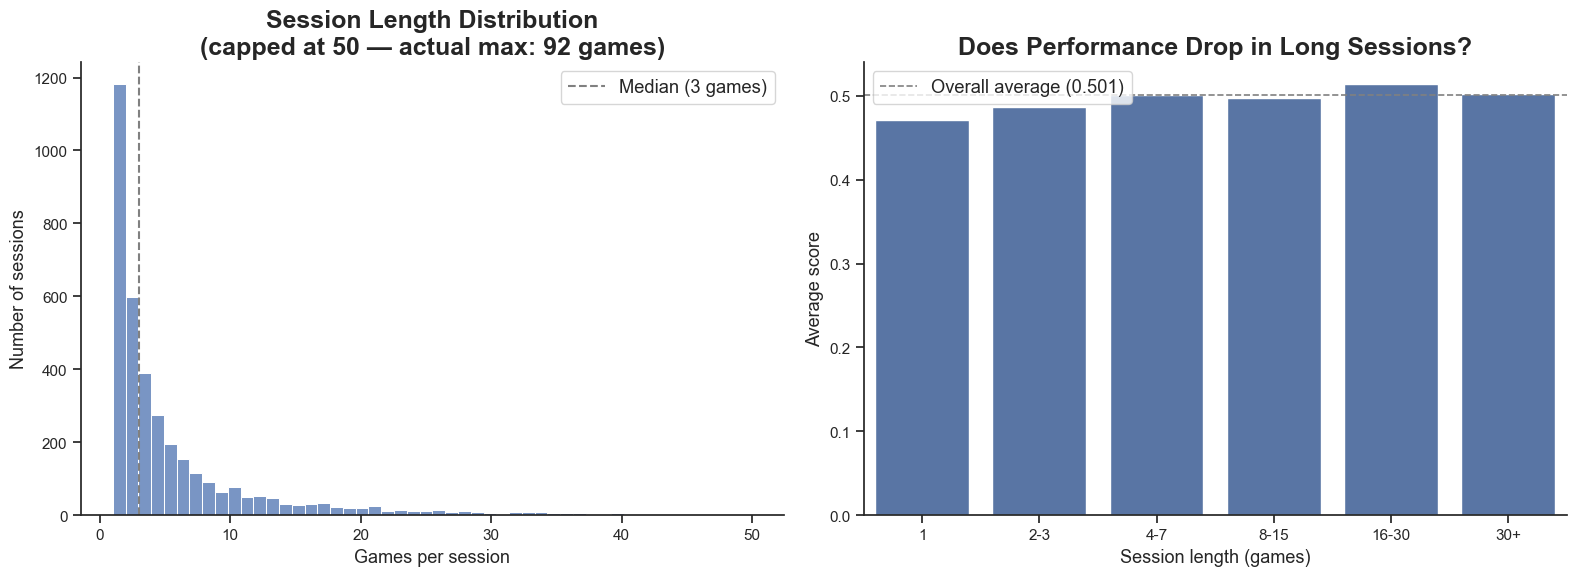

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
cap = 50
sns.histplot(
    data=sessions[sessions["games"] <= cap],
    x="games",
    bins=cap,
    ax=ax
)
ax.axvline(
    sessions["games"].median(),
    color="gray",
    linestyle="--",
    label=f"Median ({sessions['games'].median():.0f} games)"
)
ax.set_title(
    f"Session Length Distribution\n"
    f"(capped at {cap} — actual max: {sessions['games'].max()} games)"
)
ax.set_xlabel("Games per session")
ax.set_ylabel("Number of sessions")
ax.legend()
sns.despine(ax=ax)

ax2 = axes[1]
bucket_perf = (
    sessions.groupby("length_bucket", observed=True)["win_rate"]
    .mean()
    .reset_index()
)
sns.barplot(
    data=bucket_perf,
    x="length_bucket",
    y="win_rate",
    order=labels,
    ax=ax2
)
ax2.axhline(
    df["score"].mean(),
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall average ({df['score'].mean():.3f})"
)
ax2.set_title("Does Performance Drop in Long Sessions?")
ax2.set_xlabel("Session length (games)")
ax2.set_ylabel("Average score")
ax2.legend()
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "04_session_length.png", dpi=300, bbox_inches="tight")

## Chart 5 — Yearly Volume Trend

Is the habit accelerating, stable, or declining over six years?
Partial years are annotated to keep year-over-year comparisons fair.

In [13]:
yearly = (
    df.groupby("year")
    .agg(
        games=("url", "count"),
        win_rate=("score", "mean")
    )
    .reset_index()
)

partial_years = [df["year"].min(), df["year"].max()]

print(yearly.to_string(index=False))

 year  games  win_rate
 2020    287  0.526132
 2021   1715  0.508455
 2022   1208  0.498344
 2023   2917  0.495201
 2024   5820  0.501718
 2025   7610  0.500131
 2026   1450  0.496897


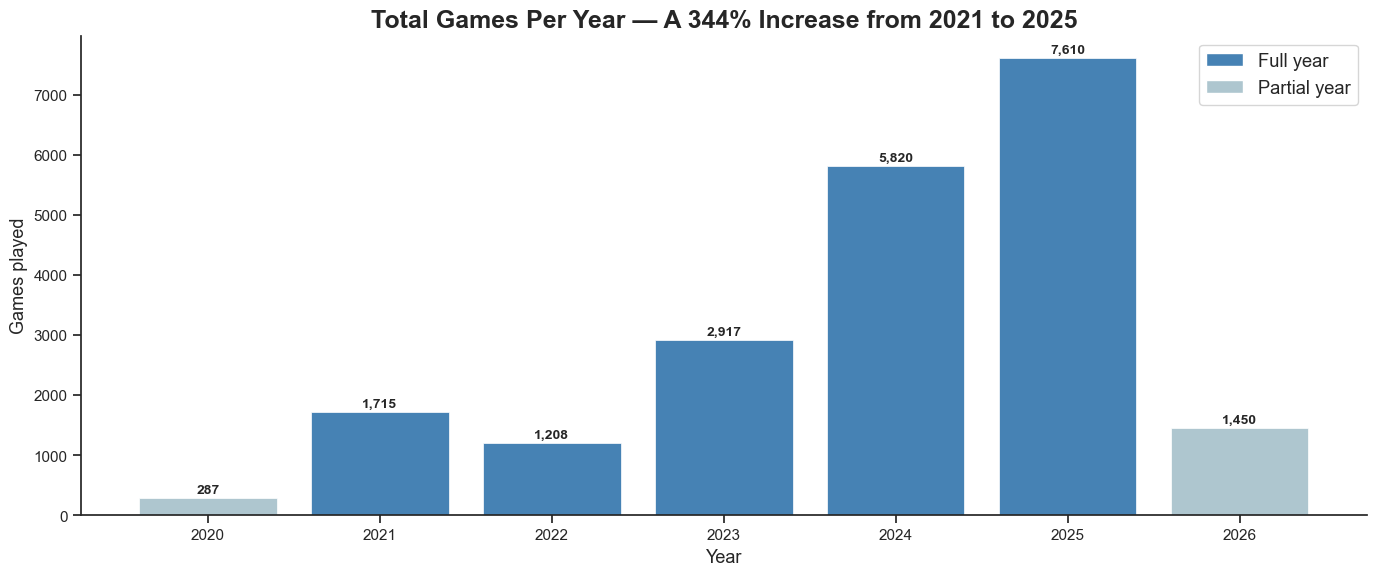

In [14]:
fig, ax = plt.subplots()

colors = [
    "#aec6cf" if y in partial_years else "steelblue"
    for y in yearly["year"]
]

bars = ax.bar(
    yearly["year"].astype(str),
    yearly["games"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

for bar, games in zip(bars, yearly["games"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{games:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


legend_elements = [
    Patch(facecolor="steelblue", label="Full year"),
    Patch(facecolor="#aec6cf", label="Partial year")
]
ax.legend(handles=legend_elements)

ax.set_title("Total Games Per Year — A 344% Increase from 2021 to 2025")
ax.set_xlabel("Year")
ax.set_ylabel("Games played")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "05_yearly_volume.png", dpi=300, bbox_inches="tight")

---

# Section B — Player Profile

These four charts provide context about who the player is and how they play.
They do not answer the behavioral question directly but give a complete
picture of the player's chess identity.

## Chart 6 — Rating Progression

In [15]:
blitz = (
    df[df["time_class"] == "blitz"]
    .sort_values("date")
)

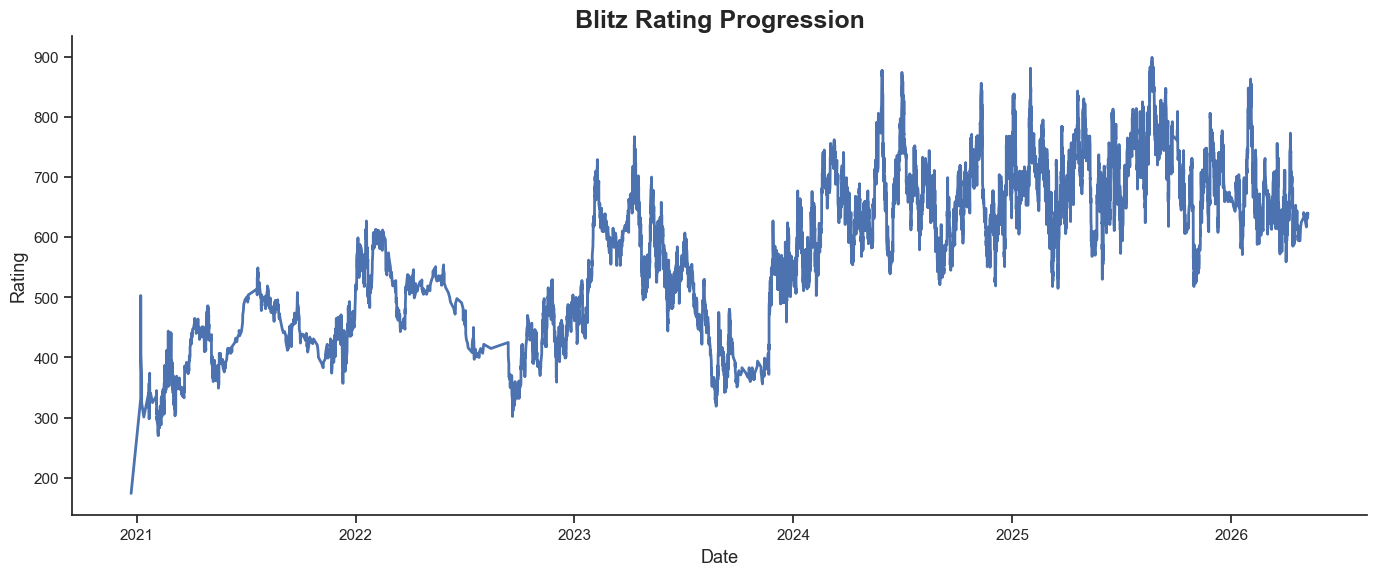

In [16]:
fig, ax = plt.subplots()

sns.lineplot(
    data=blitz,
    x="date",
    y="player_rating",
    linewidth=2,
    ax=ax
)

ax.set_title("Blitz Rating Progression")
ax.set_xlabel("Date")
ax.set_ylabel("Rating")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "06_rating_progression.png", dpi=300, bbox_inches="tight")

## Chart 7 — Performance by Hour of Day

In [17]:
hourly = (
    df.groupby("hour")
    .agg(
        score=("score", "mean"),
        games=("url", "count")
    )
    .reset_index()
)

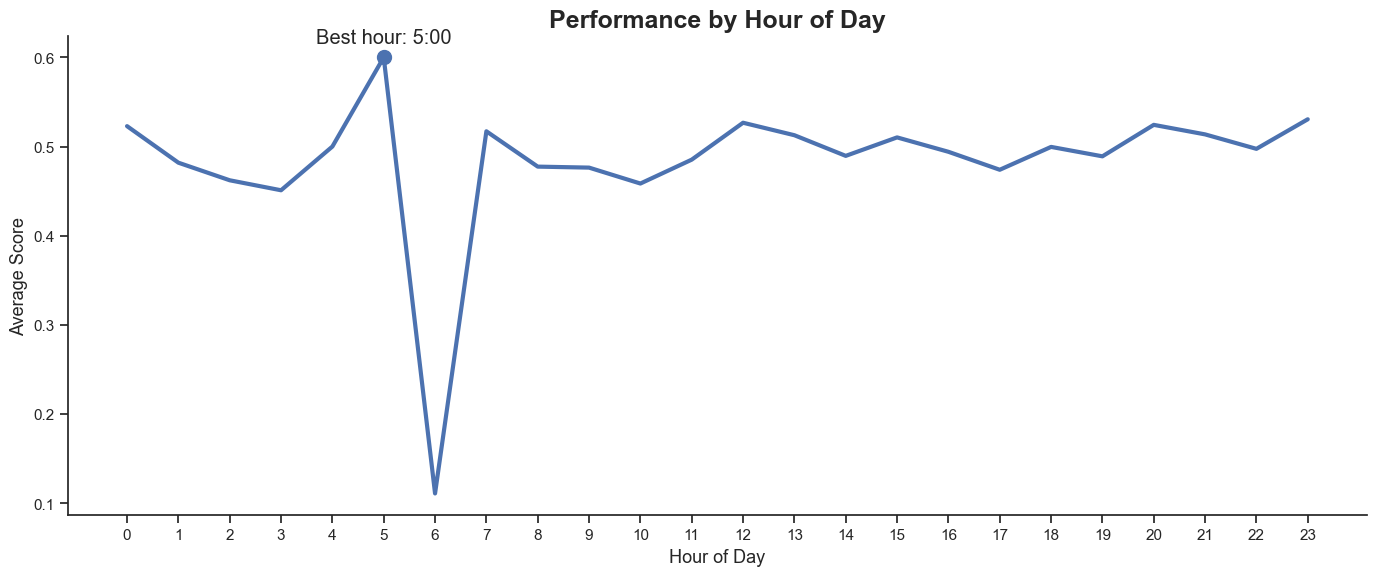

In [18]:
best_hour = hourly.loc[hourly["score"].idxmax(), "hour"]
best_score = hourly["score"].max()

fig, ax = plt.subplots()

sns.lineplot(
    data=hourly,
    x="hour",
    y="score",
    linewidth=3,
    ax=ax
)
ax.scatter(best_hour, best_score, s=100, zorder=5)
ax.annotate(
    f"Best hour: {best_hour}:00",
    (best_hour, best_score),
    textcoords="offset points",
    xytext=(0, 10),
    ha="center"
)

ax.set_title("Performance by Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Score")
ax.set_xticks(range(24))

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "07_performance_by_hour.png", dpi=300, bbox_inches="tight")

## Chart 8 — White vs Black Performance

In [19]:
side_perf = (
    df.groupby("side")
    .agg(score=("score", "mean"))
    .reset_index()
)

C:\Users\elmur\AppData\Local\Temp\ipykernel_30528\4025038234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


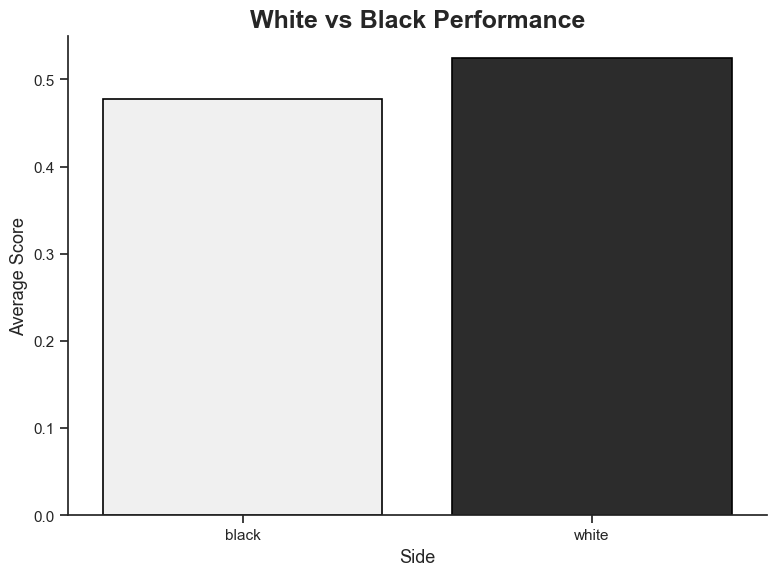

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=side_perf,
    x="side",
    y="score",
    palette=["#f0f0f0", "#2c2c2c"],
    edgecolor="black",
    linewidth=1.2,
    ax=ax
)

ax.set_title("White vs Black Performance")
ax.set_xlabel("Side")
ax.set_ylabel("Average Score")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "08_white_vs_black.png", dpi=300, bbox_inches="tight")

## Chart 9 — Best Performing Openings

Filtered to openings played at least 20 times for statistical reliability.
Top 10 by average score.

In [21]:
opening_stats = (
    df.groupby("opening")
    .agg(
        score=("score", "mean"),
        games=("url", "count")
    )
    .reset_index()
)

opening_stats = (
    opening_stats[
        opening_stats["games"] >= 20
    ]
    .sort_values("score", ascending=False)
    .head(10)
)

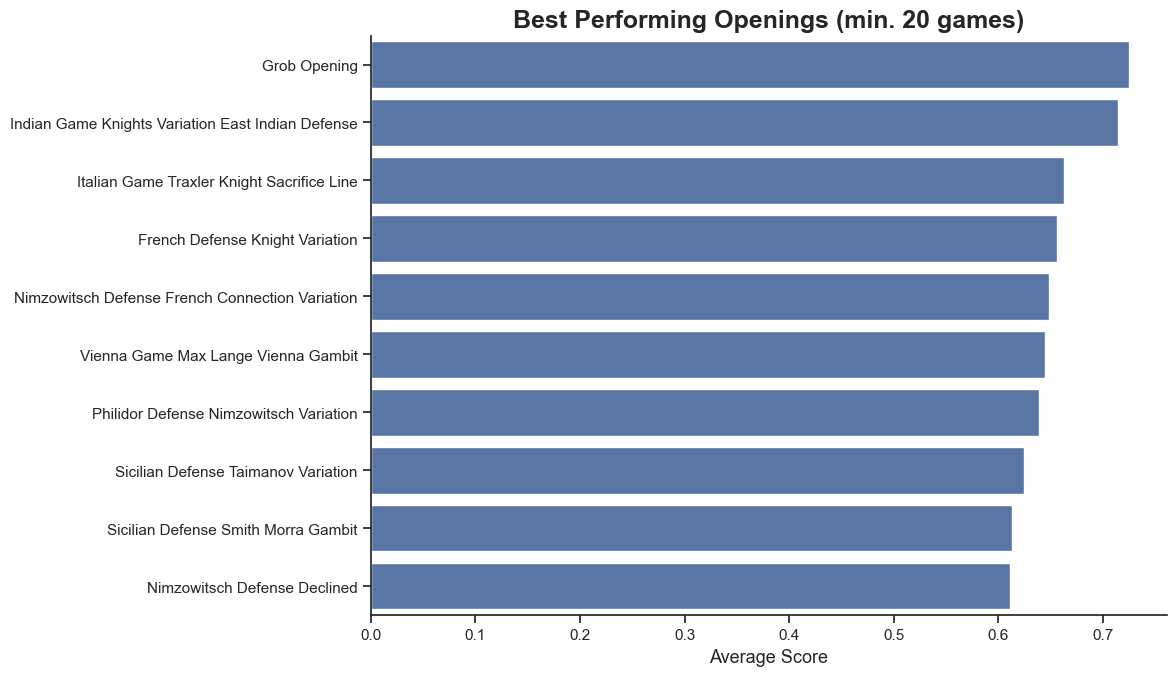

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=opening_stats,
    x="score",
    y="opening",
    orient="h",
    order=opening_stats["opening"],
    ax=ax
)

ax.set_title("Best Performing Openings (min. 20 games)")
ax.set_xlabel("Average Score")
ax.set_ylabel("")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

fig.savefig(PLOTS_DIR / "09_best_openings.png", dpi=300, bbox_inches="tight")